# 02 ICEEMDAN Decomposition and GMM-RLN Reconstruction

This notebook decomposes the eight futures/spot daily return series with a direct ICEEMDAN implementation built on `PyEMD.EMD`, then reconstructs short-, medium-, and long-term components through GMM clustering of run-length numbers.

The output tables are written to `data/processed/02_iceemdan_gmm_rln/` for the next R2 connectedness step.

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import time
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyEMD import EMD
from scipy.signal import argrelextrema, find_peaks
from scipy.stats import spearmanr
from sklearn.mixture import GaussianMixture

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "precious_metals_daily_log_returns.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "02_iceemdan_gmm_rln"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RETURN_COLUMNS = [
    "gold_futures",
    "silver_futures",
    "platinum_futures",
    "palladium_futures",
    "gold_spot",
    "silver_spot",
    "platinum_spot",
    "palladium_spot",
]

PARAMS = {
    "trials": 100,
    "epsilon": 0.2,
    "seed": 20260428,
    "spline_kind": "cubic",
    "max_imf": 12,
    "gmm_components": 3,
    "gmm_n_init": 50,
    "gmm_reg_covar": 1e-6,
    "reconstruction_tolerance": 1e-8,
}

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 10

print(f"Input: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Input: e:\@PythonProject\@Precious\precious-metal\data\processed\precious_metals_daily_log_returns.csv
Output directory: e:\@PythonProject\@Precious\precious-metal\data\processed\02_iceemdan_gmm_rln


In [2]:
returns = pd.read_csv(DATA_PATH, parse_dates=["date"])

assert list(returns.columns) == ["date", *RETURN_COLUMNS], returns.columns.tolist()
assert len(returns) == 3100, len(returns)
assert returns["date"].min() == pd.Timestamp("2012-01-04"), returns["date"].min()
assert returns["date"].max() == pd.Timestamp("2026-03-31"), returns["date"].max()
assert returns["date"].is_monotonic_increasing
assert returns["date"].duplicated().sum() == 0
assert returns[RETURN_COLUMNS].isna().sum().sum() == 0
assert all(returns[col].var() > 0 for col in RETURN_COLUMNS)

year_counts = returns.assign(year=returns["date"].dt.year).groupby("year").size()
low_common_days_after_2017 = year_counts.loc[year_counts.index >= 2017].to_dict()

input_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
input_checks = {
    "input_file": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "input_sha256": input_sha256,
    "n_rows": int(len(returns)),
    "n_series": len(RETURN_COLUMNS),
    "date_start": returns["date"].min().strftime("%Y-%m-%d"),
    "date_end": returns["date"].max().strftime("%Y-%m-%d"),
    "duplicate_dates": int(returns["date"].duplicated().sum()),
    "missing_values": int(returns[RETURN_COLUMNS].isna().sum().sum()),
    "year_counts": {str(k): int(v) for k, v in year_counts.items()},
    "limitation_note": "Common trading days decline to about 198-201 observations per full year after 2017, so long-term component interpretation should be conservative.",
}

print(json.dumps(input_checks, ensure_ascii=False, indent=2))

{
  "input_file": "data\\processed\\precious_metals_daily_log_returns.csv",
  "input_sha256": "7edc035e4616d8e9efff34acbe3ed7085e5dda8e4b91e095d4a34c92917cd15f",
  "n_rows": 3100,
  "n_series": 8,
  "date_start": "2012-01-04",
  "date_end": "2026-03-31",
  "duplicate_dates": 0,
  "missing_values": 0,
  "year_counts": {
    "2012": 251,
    "2013": 252,
    "2014": 252,
    "2015": 252,
    "2016": 252,
    "2017": 197,
    "2018": 198,
    "2019": 198,
    "2020": 201,
    "2021": 200,
    "2022": 199,
    "2023": 198,
    "2024": 198,
    "2025": 198,
    "2026": 54
  },
  "limitation_note": "Common trading days decline to about 198-201 observations per full year after 2017, so long-term component interpretation should be conservative."
}


In [3]:
@dataclass(frozen=True)
class DecompositionResult:
    imfs: np.ndarray
    residue: np.ndarray
    elapsed_seconds: float


def count_extrema(values: np.ndarray) -> int:
    values = np.asarray(values, dtype=float)
    if values.size < 3:
        return 0
    maxima = argrelextrema(values, np.greater)[0]
    minima = argrelextrema(values, np.less)[0]
    return int(len(maxima) + len(minima))


def emd_imfs_and_residue(emd: EMD, values: np.ndarray, max_imf: int = -1) -> tuple[np.ndarray, np.ndarray]:
    values = np.asarray(values, dtype=float)
    emd.emd(values, max_imf=max_imf)
    imfs, residue = emd.get_imfs_and_residue()
    if imfs.size == 0:
        return np.empty((0, values.size)), values.copy()
    return np.asarray(imfs, dtype=float), np.asarray(residue, dtype=float)


def local_mean(emd: EMD, values: np.ndarray) -> np.ndarray:
    """ICEEMDAN M(.) operator: residue after extracting the first IMF by EMD."""
    imfs, residue = emd_imfs_and_residue(emd, values, max_imf=1)
    if imfs.shape[0] == 0:
        return np.asarray(values, dtype=float).copy()
    return residue


def normalize_rows(values: np.ndarray) -> np.ndarray:
    means = values.mean(axis=1, keepdims=True)
    stds = values.std(axis=1, keepdims=True)
    return np.divide(values - means, stds, out=np.zeros_like(values), where=stds > 0)


def normalize_imfs(imfs: np.ndarray) -> np.ndarray:
    if imfs.size == 0:
        return imfs
    stds = imfs.std(axis=1, keepdims=True)
    return np.divide(imfs, stds, out=np.zeros_like(imfs), where=stds > 0)


def iceemdan_decompose(
    values: np.ndarray,
    *,
    trials: int,
    epsilon: float,
    seed: int,
    spline_kind: str,
    max_imf: int,
) -> DecompositionResult:
    """Direct ICEEMDAN implementation using PyEMD.EMD only.

    This follows the iterative residue construction in Colominas et al. (2014):
    M(.) is estimated by the local mean from EMD, white-noise IMFs E_k(w_i) are
    precomputed, and each IMF is obtained as the difference of consecutive residues.
    """
    start = time.perf_counter()
    values = np.asarray(values, dtype=float)
    n_obs = values.size
    signal_std = float(values.std(ddof=0))
    if signal_std <= 0:
        raise ValueError("ICEEMDAN requires a non-constant input series.")

    rng = np.random.default_rng(seed)
    emd = EMD(spline_kind=spline_kind)

    noises = normalize_rows(rng.standard_normal((trials, n_obs)))
    noise_imfs: list[np.ndarray] = []
    for noise in noises:
        imfs, _ = emd_imfs_and_residue(emd, noise, max_imf=max_imf)
        noise_imfs.append(normalize_imfs(imfs))

    def kth_noise_imf(trial_idx: int, imf_idx: int) -> np.ndarray:
        imfs = noise_imfs[trial_idx]
        if imf_idx < imfs.shape[0]:
            return imfs[imf_idx]
        return np.zeros(n_obs)

    first_residues = [
        local_mean(emd, values + epsilon * signal_std * kth_noise_imf(trial_idx, 0))
        for trial_idx in range(trials)
    ]
    previous_residue = np.mean(first_residues, axis=0)
    modes = [values - previous_residue]

    for imf_idx in range(1, max_imf):
        if count_extrema(previous_residue) < 2:
            break
        beta = epsilon * float(previous_residue.std(ddof=0))
        next_residues = [
            local_mean(emd, previous_residue + beta * kth_noise_imf(trial_idx, imf_idx))
            for trial_idx in range(trials)
        ]
        next_residue = np.mean(next_residues, axis=0)
        mode = previous_residue - next_residue
        if np.allclose(mode, 0.0, atol=1e-12, rtol=0.0):
            break
        modes.append(mode)
        previous_residue = next_residue

    imfs = np.vstack(modes)
    residue = values - imfs.sum(axis=0)
    elapsed = time.perf_counter() - start
    return DecompositionResult(imfs=imfs, residue=residue, elapsed_seconds=elapsed)


def run_length_number(values: np.ndarray) -> int:
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return 0
    symbols = np.where(values >= values.mean(), 1, -1)
    return int(1 + np.sum(symbols[1:] != symbols[:-1]))


def mean_period(values: np.ndarray) -> float:
    peaks, _ = find_peaks(np.asarray(values, dtype=float))
    if len(peaks) == 0:
        return np.inf
    return float(len(values) / len(peaks))


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    corr = spearmanr(x, y, nan_policy="omit").correlation
    return float(corr) if pd.notna(corr) else np.nan

In [4]:
decomposition_results: dict[str, DecompositionResult] = {}
reconstruction_errors: dict[str, float] = {}

for series_idx, series_name in enumerate(RETURN_COLUMNS):
    series_seed = PARAMS["seed"] + series_idx
    values = returns[series_name].to_numpy(dtype=float)
    result = iceemdan_decompose(
        values,
        trials=PARAMS["trials"],
        epsilon=PARAMS["epsilon"],
        seed=series_seed,
        spline_kind=PARAMS["spline_kind"],
        max_imf=PARAMS["max_imf"],
    )
    decomposition_results[series_name] = result
    recon_error = float(np.max(np.abs(result.imfs.sum(axis=0) + result.residue - values)))
    reconstruction_errors[series_name] = recon_error
    print(
        f"{series_name}: {result.imfs.shape[0]} IMFs + residue, "
        f"{result.elapsed_seconds:.2f}s, max reconstruction error={recon_error:.3e}"
    )

max_reconstruction_error = max(reconstruction_errors.values())
assert max_reconstruction_error < PARAMS["reconstruction_tolerance"], reconstruction_errors

gold_futures: 10 IMFs + residue, 8.11s, max reconstruction error=6.939e-18
silver_futures: 10 IMFs + residue, 8.22s, max reconstruction error=6.939e-18
platinum_futures: 10 IMFs + residue, 7.60s, max reconstruction error=3.469e-18
palladium_futures: 9 IMFs + residue, 7.59s, max reconstruction error=1.735e-18
gold_spot: 10 IMFs + residue, 7.99s, max reconstruction error=6.939e-18
silver_spot: 10 IMFs + residue, 7.87s, max reconstruction error=8.674e-19
platinum_spot: 10 IMFs + residue, 7.72s, max reconstruction error=3.469e-18
palladium_spot: 10 IMFs + residue, 8.06s, max reconstruction error=6.939e-18


In [5]:
dates = returns["date"].to_numpy()
imf_rows = []
diagnostic_rows = []
component_long_rows = []
component_wide = pd.DataFrame({"date": returns["date"]})
scale_reconstruction_errors: dict[str, float] = {}
gmm_scale_counts: dict[str, dict[str, int]] = {}
period_warnings: list[str] = []

for series_name, result in decomposition_results.items():
    original = returns[series_name].to_numpy(dtype=float)
    component_variances = [np.var(mode, ddof=0) for mode in result.imfs]
    component_variances.append(np.var(result.residue, ddof=0))
    variance_denominator = float(np.sum(component_variances))

    imf_run_lengths = np.array([run_length_number(mode) for mode in result.imfs], dtype=float)
    if result.imfs.shape[0] < PARAMS["gmm_components"]:
        raise ValueError(f"{series_name} produced fewer than 3 IMFs and cannot be reconstructed with 3 GMM-RLN scales.")

    gmm = GaussianMixture(
        n_components=PARAMS["gmm_components"],
        n_init=PARAMS["gmm_n_init"],
        reg_covar=PARAMS["gmm_reg_covar"],
        random_state=PARAMS["seed"],
    )
    cluster_labels = gmm.fit_predict(imf_run_lengths.reshape(-1, 1))
    observed_labels = sorted(set(int(label) for label in cluster_labels))
    if len(observed_labels) != PARAMS["gmm_components"]:
        raise ValueError(f"{series_name} GMM assigned fewer than 3 non-empty scale groups: {observed_labels}")

    label_means = {
        label: float(imf_run_lengths[cluster_labels == label].mean())
        for label in observed_labels
    }
    ordered_labels = sorted(label_means, key=label_means.get, reverse=True)
    label_to_scale = dict(zip(ordered_labels, ["STC", "MTC", "LTC"]))

    imf_periods = []
    scale_components = {"STC": np.zeros_like(original), "MTC": np.zeros_like(original), "LTC": np.zeros_like(original)}

    for imf_idx, mode in enumerate(result.imfs, start=1):
        mode_name = f"IMF{imf_idx}"
        scale = label_to_scale[int(cluster_labels[imf_idx - 1])]
        scale_components[scale] += mode
        period = mean_period(mode)
        imf_periods.append(period)
        rln = int(imf_run_lengths[imf_idx - 1])
        variance_contribution = float(np.var(mode, ddof=0) / variance_denominator) if variance_denominator > 0 else np.nan

        diagnostic_rows.append(
            {
                "series": series_name,
                "mode": mode_name,
                "mode_order": imf_idx,
                "mean_period": period,
                "spearman_corr": safe_spearman(mode, original),
                "variance_contribution": variance_contribution,
                "run_length_number": rln,
                "gmm_cluster": int(cluster_labels[imf_idx - 1]),
                "gmm_cluster_mean_rln": label_means[int(cluster_labels[imf_idx - 1])],
                "scale": scale,
            }
        )
        imf_rows.extend(
            {"date": date, "series": series_name, "mode": mode_name, "mode_order": imf_idx, "value": value}
            for date, value in zip(returns["date"], mode)
        )

    if np.any(np.diff(imf_periods) < 0):
        message = f"{series_name}: IMF mean periods are not strictly non-decreasing. Real decomposition results are retained."
        warnings.warn(message)
        period_warnings.append(message)

    scale_components["LTC"] += result.residue
    residue_order = result.imfs.shape[0] + 1
    diagnostic_rows.append(
        {
            "series": series_name,
            "mode": "residue",
            "mode_order": residue_order,
            "mean_period": np.inf,
            "spearman_corr": safe_spearman(result.residue, original),
            "variance_contribution": float(np.var(result.residue, ddof=0) / variance_denominator) if variance_denominator > 0 else np.nan,
            "run_length_number": np.nan,
            "gmm_cluster": np.nan,
            "gmm_cluster_mean_rln": np.nan,
            "scale": "LTC",
        }
    )
    imf_rows.extend(
        {"date": date, "series": series_name, "mode": "residue", "mode_order": residue_order, "value": value}
        for date, value in zip(returns["date"], result.residue)
    )

    reconstructed = scale_components["STC"] + scale_components["MTC"] + scale_components["LTC"]
    scale_error = float(np.max(np.abs(reconstructed - original)))
    scale_reconstruction_errors[series_name] = scale_error
    assert scale_error < PARAMS["reconstruction_tolerance"], (series_name, scale_error)

    scale_counts = {scale: 0 for scale in ["STC", "MTC", "LTC"]}
    for label in cluster_labels:
        scale_counts[label_to_scale[int(label)]] += 1
    if any(count == 0 for count in scale_counts.values()):
        raise ValueError(f"{series_name} has an empty GMM-RLN scale group: {scale_counts}")
    gmm_scale_counts[series_name] = scale_counts

    for scale in ["STC", "MTC", "LTC"]:
        values = scale_components[scale]
        component_wide[f"{series_name}_{scale}"] = values
        component_long_rows.extend(
            {"date": date, "series": series_name, "scale": scale, "value": value}
            for date, value in zip(returns["date"], values)
        )

iceemdan_imfs_long = pd.DataFrame(imf_rows)
iceemdan_diagnostics = pd.DataFrame(diagnostic_rows)
gmm_rln_components_long = pd.DataFrame(component_long_rows)
gmm_rln_components_wide = component_wide.copy()

assert gmm_rln_components_wide.shape == (3100, 25), gmm_rln_components_wide.shape
assert gmm_rln_components_wide.drop(columns=["date"]).shape[1] == 24
assert max(scale_reconstruction_errors.values()) < PARAMS["reconstruction_tolerance"]

print("GMM-RLN scale counts by series:")
display(pd.DataFrame(gmm_scale_counts).T)
print("Max ICEEMDAN reconstruction error:", max_reconstruction_error)
print("Max scale reconstruction error:", max(scale_reconstruction_errors.values()))
if period_warnings:
    print("Mean-period warnings:")
    for message in period_warnings:
        print("-", message)

GMM-RLN scale counts by series:


,STC,MTC,LTC
gold_futures,1,1,8
silver_futures,1,1,8
platinum_futures,1,1,8
palladium_futures,1,1,7
gold_spot,1,1,8
silver_spot,1,1,8
platinum_spot,1,1,8
palladium_spot,1,1,8


Max ICEEMDAN reconstruction error: 6.938893903907228e-18
Max scale reconstruction error: 7.105427357601002e-15


In [6]:
iceemdan_imfs_long.to_csv(OUTPUT_DIR / "iceemdan_imfs_long.csv", index=False, encoding="utf-8-sig")
iceemdan_diagnostics.to_csv(OUTPUT_DIR / "iceemdan_diagnostics.csv", index=False, encoding="utf-8-sig")
gmm_rln_components_long.to_csv(OUTPUT_DIR / "gmm_rln_components_long.csv", index=False, encoding="utf-8-sig")
gmm_rln_components_wide.to_csv(OUTPUT_DIR / "gmm_rln_components_wide.csv", index=False, encoding="utf-8-sig")

manifest = {
    "method": "Direct ICEEMDAN implementation using PyEMD.EMD local-mean operator; PyEMD.CEEMDAN is not used.",
    "parameters": PARAMS,
    "input_checks": input_checks,
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "outputs": {
        "iceemdan_imfs_long": "data/processed/02_iceemdan_gmm_rln/iceemdan_imfs_long.csv",
        "iceemdan_diagnostics": "data/processed/02_iceemdan_gmm_rln/iceemdan_diagnostics.csv",
        "gmm_rln_components_long": "data/processed/02_iceemdan_gmm_rln/gmm_rln_components_long.csv",
        "gmm_rln_components_wide": "data/processed/02_iceemdan_gmm_rln/gmm_rln_components_wide.csv",
    },
    "n_imfs_by_series": {series: int(result.imfs.shape[0]) for series, result in decomposition_results.items()},
    "decomposition_seconds_by_series": {series: round(float(result.elapsed_seconds), 4) for series, result in decomposition_results.items()},
    "iceemdan_reconstruction_error_by_series": reconstruction_errors,
    "scale_reconstruction_error_by_series": scale_reconstruction_errors,
    "gmm_scale_counts_by_series": gmm_scale_counts,
    "mean_period_warnings": period_warnings,
    "limitation_note": input_checks["limitation_note"],
}

with open(OUTPUT_DIR / "run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

for path in [
    OUTPUT_DIR / "iceemdan_imfs_long.csv",
    OUTPUT_DIR / "iceemdan_diagnostics.csv",
    OUTPUT_DIR / "gmm_rln_components_long.csv",
    OUTPUT_DIR / "gmm_rln_components_wide.csv",
    OUTPUT_DIR / "run_manifest.json",
]:
    print(path.relative_to(PROJECT_ROOT), path.stat().st_size)

data\processed\02_iceemdan_gmm_rln\iceemdan_imfs_long.csv 14626464
data\processed\02_iceemdan_gmm_rln\iceemdan_diagnostics.csv 8614
data\processed\02_iceemdan_gmm_rln\gmm_rln_components_long.csv 3717468
data\processed\02_iceemdan_gmm_rln\gmm_rln_components_wide.csv 1504487
data\processed\02_iceemdan_gmm_rln\run_manifest.json 4017


In [7]:
display(iceemdan_diagnostics.head(20))

gmm_summary = (
    iceemdan_diagnostics.loc[iceemdan_diagnostics["mode"].str.startswith("IMF")]
    .groupby(["series", "scale"])
    .agg(
        n_modes=("mode", "count"),
        min_mode_order=("mode_order", "min"),
        max_mode_order=("mode_order", "max"),
        mean_rln=("run_length_number", "mean"),
        mean_period=("mean_period", "mean"),
        variance_contribution=("variance_contribution", "sum"),
    )
    .reset_index()
    .sort_values(["series", "scale"])
)
display(gmm_summary)

,series,mode,mode_order,mean_period,spearman_corr,variance_contribution,run_length_number,gmm_cluster,gmm_cluster_mean_rln,scale
0,gold_futures,IMF1,1,2.716915,0.738333,0.580444,2181.0,2.0,2181.000,STC
1,gold_futures,IMF2,2,5.486726,0.425427,0.208505,1081.0,0.0,1081.000,MTC
2,gold_futures,IMF3,3,11.032028,0.273024,0.109131,519.0,1.0,129.500,LTC
3,gold_futures,IMF4,4,21.527778,0.219481,0.057473,266.0,1.0,129.500,LTC
4,gold_futures,IMF5,5,41.333333,0.160755,0.023842,134.0,1.0,129.500,LTC
5,gold_futures,IMF6,6,88.571429,0.090253,0.013120,66.0,1.0,129.500,LTC
6,gold_futures,IMF7,7,206.666667,0.066355,0.004217,27.0,1.0,129.500,LTC
7,gold_futures,IMF8,8,442.857143,0.033870,0.000946,13.0,1.0,129.500,LTC
8,gold_futures,IMF9,9,775.000000,0.054364,0.001395,7.0,1.0,129.500,LTC
9,gold_futures,IMF10,10,3100.000000,0.018743,0.000251,4.0,1.0,129.500,LTC


,series,scale,n_modes,min_mode_order,max_mode_order,mean_rln,mean_period,variance_contribution
0,gold_futures,LTC,8,3,10,129.500,585.873547,0.210375
1,gold_futures,MTC,1,2,2,1081.000,5.486726,0.208505
2,gold_futures,STC,1,1,1,2181.000,2.716915,0.580444
3,gold_spot,LTC,8,3,10,133.375,392.364926,0.222442
4,gold_spot,MTC,1,2,2,1078.000,5.391304,0.193344
5,gold_spot,STC,1,1,1,2173.000,2.731278,0.583802
6,palladium_futures,LTC,7,3,9,146.000,370.607331,0.197603
7,palladium_futures,MTC,1,2,2,1068.000,5.506217,0.243351
8,palladium_futures,STC,1,1,1,2120.000,2.724077,0.559005
9,palladium_spot,LTC,8,3,10,132.125,690.534340,0.239517


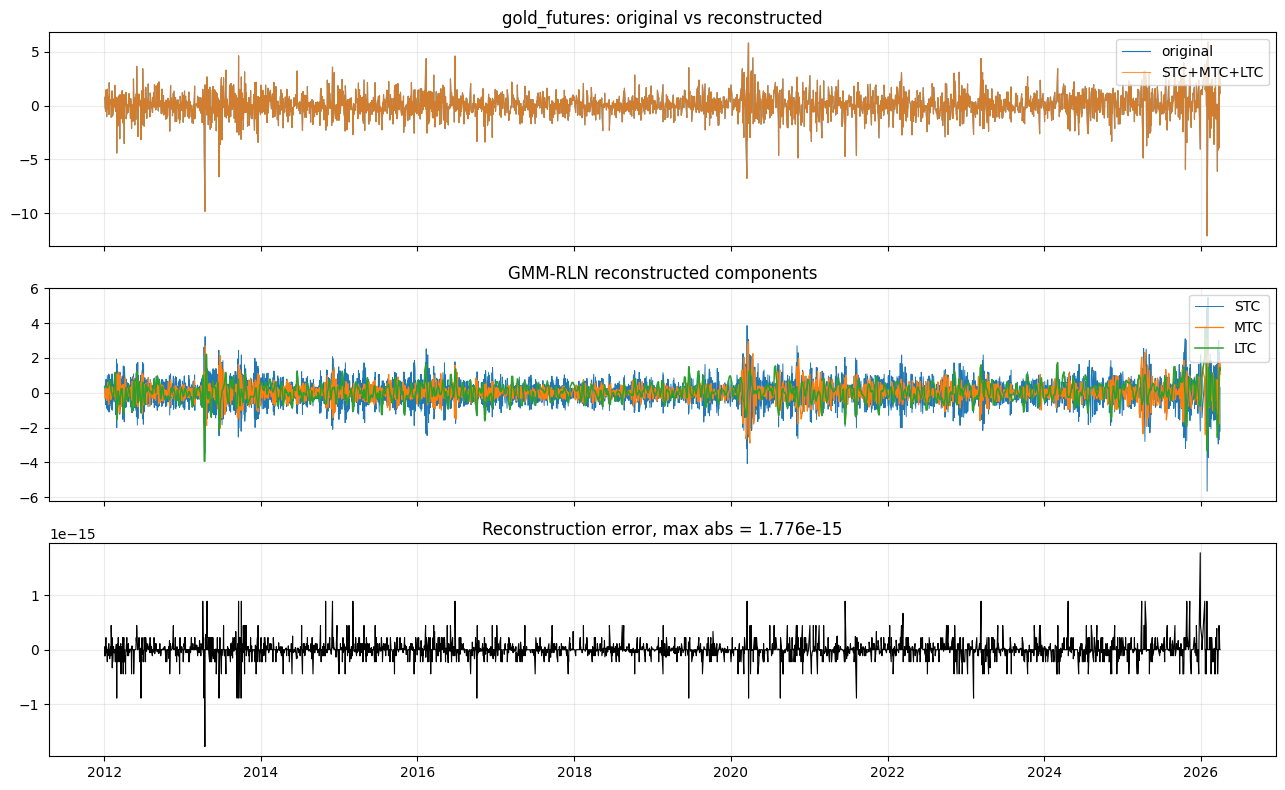

In [8]:
example_series = "gold_futures"
example = returns[["date", example_series]].merge(
    gmm_rln_components_wide[["date", f"{example_series}_STC", f"{example_series}_MTC", f"{example_series}_LTC"]],
    on="date",
)
example["reconstructed"] = example[[f"{example_series}_STC", f"{example_series}_MTC", f"{example_series}_LTC"]].sum(axis=1)
example["error"] = example["reconstructed"] - example[example_series]

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(example["date"], example[example_series], label="original", linewidth=0.8)
axes[0].plot(example["date"], example["reconstructed"], label="STC+MTC+LTC", linewidth=0.8, alpha=0.8)
axes[0].set_title(f"{example_series}: original vs reconstructed")
axes[0].legend(loc="upper right")
axes[1].plot(example["date"], example[f"{example_series}_STC"], label="STC", linewidth=0.7)
axes[1].plot(example["date"], example[f"{example_series}_MTC"], label="MTC", linewidth=0.9)
axes[1].plot(example["date"], example[f"{example_series}_LTC"], label="LTC", linewidth=1.1)
axes[1].set_title("GMM-RLN reconstructed components")
axes[1].legend(loc="upper right")
axes[2].plot(example["date"], example["error"], color="black", linewidth=0.8)
axes[2].set_title(f"Reconstruction error, max abs = {example['error'].abs().max():.3e}")
plt.tight_layout()
plt.show()

## Research Limitation for the Next Step

This second-stage decomposition is ready for the R2 connectedness notebook. The current empirical sample is still the available 2012-2026 panel; because the common trading-day intersection drops to roughly 198-201 observations per full year after 2017, long-term component interpretation should be treated more conservatively than in a 24-year sample.